# Análisis GitLeaks: Secretos Expuestos en Código Fuente de una organización

## Link al repositorio: [Link Github](https://github.com/Sunnaee/icc610tarea5)

## Integrantes: 
- David Baez.
- Martín Carrasco.
- Sabrina López.

## Introducción
Este notebook presenta un descriptivo de los resultados obtenidos mediante **GitLeaks**, una herramienta de análisis de seguridad enfocada en la publicación de contraseñas, archivos secrets en proyectos de Git.

## Caso de análisis
En base al análisis de la Tarea 4, se intento obtener los _secrets_, de _Github Actions_, sin embargo, no se encontraron resultados. Es por ello que se cambio a la organización utilizada en el proyecto: **Vercel**.

Vercel es un compañia estadounidense que se centra en proveer de herramientas de desarrollo e infraestructura cloud para sitios webs, especialmente para _frontend_. Su selección fue producto de la brecha ocurra en abril de este año, donde al infectarse el ordenar de un desarrollador, se obtuvo acceso a claves de una gran cantidad de usuarios, comprometiendo su seguridad.

In [3]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setup de rutas
project_root = Path().cwd().parent.parent
scripts_path = project_root / "scripts"
if str(scripts_path) not in sys.path:
    sys.path.append(str(scripts_path))
data_results = project_root / "data" / "results"

print(f"Directorio de resultados: {data_results}")
print(f"✓ Proyecto raíz: {project_root}")

Directorio de resultados: /workspaces/TareaGitLeaks/data/results
✓ Proyecto raíz: /workspaces/TareaGitLeaks


## Repositorios análizados

Para la selección de los repositorios se utilizaron los 25 con más estrellas de la organización. Para ello son obtenidos por medio de uso de la API de Github. A continuación se mostrarán los repositorios en pantalla por medio del objeto encargado de hacer las consultas y guardarlos.

In [4]:
from generate_github_api import GetReposGitHubAPI
print("✓ Módulo de GitHub API importado correctamente")

✓ Módulo de GitHub API importado correctamente


In [6]:
get_repos = GetReposGitHubAPI("/data/repos/", "vercel")
repos = get_repos.get_useful_repos(25)
for repo in repos:
    print(f"Repositorio: {repo['name']} - Stars: {repo['stargazers_count']}")

Repositorio: next.js - Stars: 139396
Repositorio: hyper - Stars: 44578
Repositorio: swr - Stars: 32379
Repositorio: pkg - Stars: 24377
Repositorio: ai - Stars: 24162
Repositorio: chatbot - Stars: 20281
Repositorio: vercel - Stars: 15467
Repositorio: commerce - Stars: 14033
Repositorio: satori - Stars: 13403
Repositorio: micro - Stars: 10610
Repositorio: serve - Stars: 9852
Repositorio: ncc - Stars: 9805
Repositorio: styled-jsx - Stars: 7791
Repositorio: nextjs-subscription-payments - Stars: 7717
Repositorio: next-forge - Stars: 7065
Repositorio: platforms - Stars: 6677
Repositorio: ms - Stars: 5527
Repositorio: streamdown - Stars: 5174
Repositorio: examples - Stars: 5072
Repositorio: next-learn - Stars: 4715
Repositorio: og-image - Stars: 4055
Repositorio: release - Stars: 3585
Repositorio: hazel - Stars: 3021
Repositorio: next-app-router-playground - Stars: 2983
Repositorio: kirimase - Stars: 2798


In [25]:
# Cargar todos los análisis GitLeaks
gitleaks_files = sorted(data_results.glob("*gitleaks.json"))

print(f"\nBuscando archivos GitLeaks en: {data_results}")
print(f"✓ Archivos encontrados: {len(gitleaks_files)}\n")

# Consolidar en un solo DataFrame
data_consolidado = []

for archivo in gitleaks_files:
    with open(archivo, 'r', encoding='utf-8') as f:
        try:
            contenido = json.load(f)
        except json.JSONDecodeError:
            print(
                f"Advertencia: Archivo vacío o mal formado -> {archivo.name}")
            continue

    repo_name = archivo.stem.replace('_gitleaks', '')

    # Manejar caso de listas vs objetos
    if isinstance(contenido, list):
        issues = contenido
    else:
        issues = []

    for issue in issues:
        issue['repo'] = repo_name
        data_consolidado.append(issue)

df_gitleaks = pd.DataFrame(data_consolidado)

print(f"Total de secretos expuestos cargados: {len(df_gitleaks)}")
print(
    f"Repositorios únicos con filtraciones: {df_gitleaks['repo'].nunique() if len(df_gitleaks) > 0 else 0}\n")


Buscando archivos GitLeaks en: /workspaces/TareaGitLeaks/data/results
✓ Archivos encontrados: 25

Total de secretos expuestos cargados: 350
Repositorios únicos con filtraciones: 11



In [26]:
# Estadísticas por Regla
if len(df_gitleaks) > 0:
    stats_rules = df_gitleaks['RuleID'].value_counts()

    print("Tipos de Secretos Encontrados (RuleID):")
    print("=" * 60)
    for regla, cantidad in stats_rules.items():
        porcentaje = (cantidad / len(df_gitleaks)) * 100
        print(f"{regla:<30} {cantidad:>5} ({porcentaje:.1f}%)")

    print(f"\nTotal general: {len(df_gitleaks)} secretos detectados")
else:
    print("No hay datos de GitLeaks disponibles")

Tipos de Secretos Encontrados (RuleID):
generic-api-key                  241 (68.9%)
private-key                       86 (24.6%)
gcp-api-key                       11 (3.1%)
jwt                                8 (2.3%)
curl-auth-header                   2 (0.6%)
aws-access-token                   2 (0.6%)

Total general: 350 secretos detectados


In [27]:
# Estadísticas por Regla

filter_words = ["test", "examples", "docs", "sample", "samples", "demo",
                "demos", "template", "templates", "example", "tests", "doc",  "documentation"]

if len(df_gitleaks) > 0:
    # 1. Create a regex pattern combining words with OR (|)
    pattern = '|'.join(filter_words)

    # 2. Filter out rows where the 'File' column contains any of these words
    # (~ inverts the boolean mask to KEEP rows that DO NOT match)
    df_filtered = df_gitleaks[~df_gitleaks['File'].str.contains(
        pattern, case=False, na=False)]

    # 3. Perform the same count operation on the filtered dataframe
    stats_rules = df_filtered['RuleID'].value_counts()

    print("Tipos de Secretos Encontrados (Filtrado):")
    print("=" * 60)
    for regla, cantidad in stats_rules.items():
        porcentaje = (cantidad / len(df_filtered)) * 100
        print(f"{regla:<30} {cantidad:>5} ({porcentaje:.1f}%)")

    print(
        f"\nTotal general: {len(df_filtered)} secretos detectados (después de filtrar)")

Tipos de Secretos Encontrados (Filtrado):
generic-api-key                   97 (55.1%)
private-key                       70 (39.8%)
gcp-api-key                        5 (2.8%)
jwt                                4 (2.3%)

Total general: 176 secretos detectados (después de filtrar)


Se decide realizar un filtro sobre ciertas palabras para limpiar los resultados.

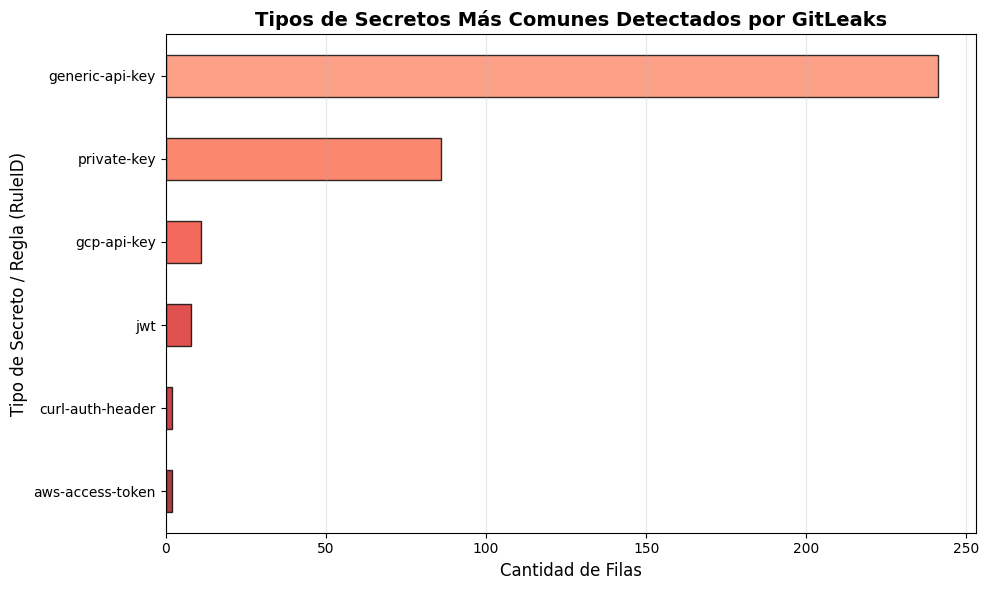

In [28]:
# Gráfico: Top Secretos por regla
if len(df_gitleaks) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    top_rules = df_gitleaks['RuleID'].value_counts().head(10)

    # Colores del gradiente
    colores_gradiente = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_rules)))

    # Se invierte para que el mayor quede arriba en un barh
    top_rules[::-1].plot(kind='barh', ax=ax,
                         color=colores_gradiente[::-1], edgecolor='black', alpha=0.8)

    ax.set_title('Tipos de Secretos Más Comunes Detectados por GitLeaks',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Filas', fontsize=12)
    ax.set_ylabel('Tipo de Secreto / Regla (RuleID)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

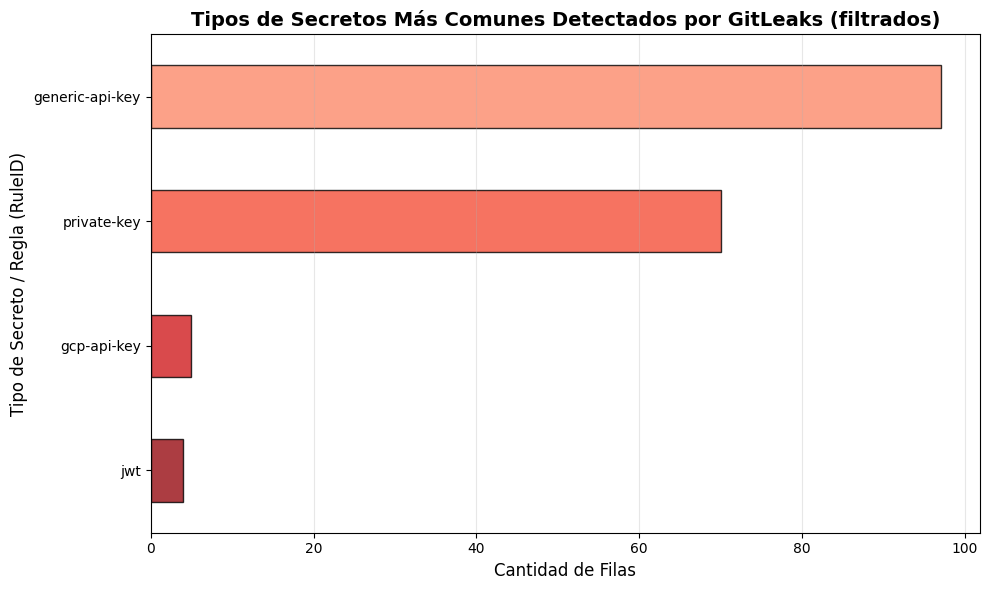

In [29]:
# Gráfico: Top Secretos por regla
if len(df_gitleaks) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))

    top_rules = stats_rules.head(10)  # Usar stats_rules filtrado

    # Colores del gradiente
    colores_gradiente = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_rules)))

    # Se invierte para que el mayor quede arriba en un barh
    top_rules[::-1].plot(kind='barh', ax=ax,
                         color=colores_gradiente[::-1], edgecolor='black', alpha=0.8)

    ax.set_title('Tipos de Secretos Más Comunes Detectados por GitLeaks (filtrados)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Cantidad de Filas', fontsize=12)
    ax.set_ylabel('Tipo de Secreto / Regla (RuleID)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

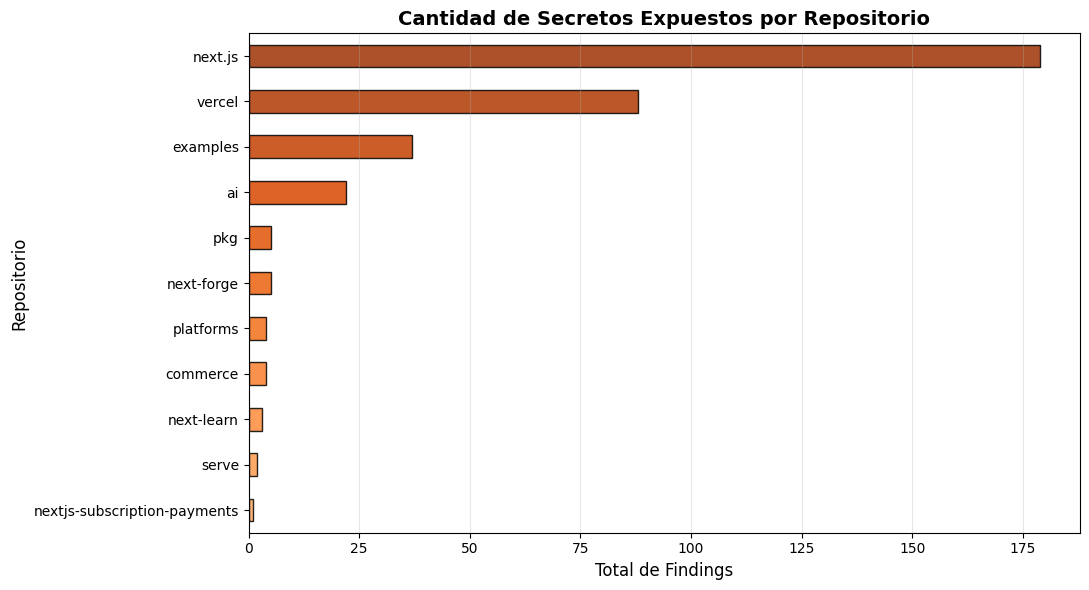

In [30]:
# Gráfico: Secretos por repositorio
if len(df_gitleaks) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    issues_por_repo = df_gitleaks['repo'].value_counts(
    ).sort_values(ascending=True)

    # Colores del gradiente
    colores_gradiente = plt.cm.Oranges(
        np.linspace(0.4, 0.9, len(issues_por_repo)))

    issues_por_repo.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Cantidad de Secretos Expuestos por Repositorio',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Findings', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

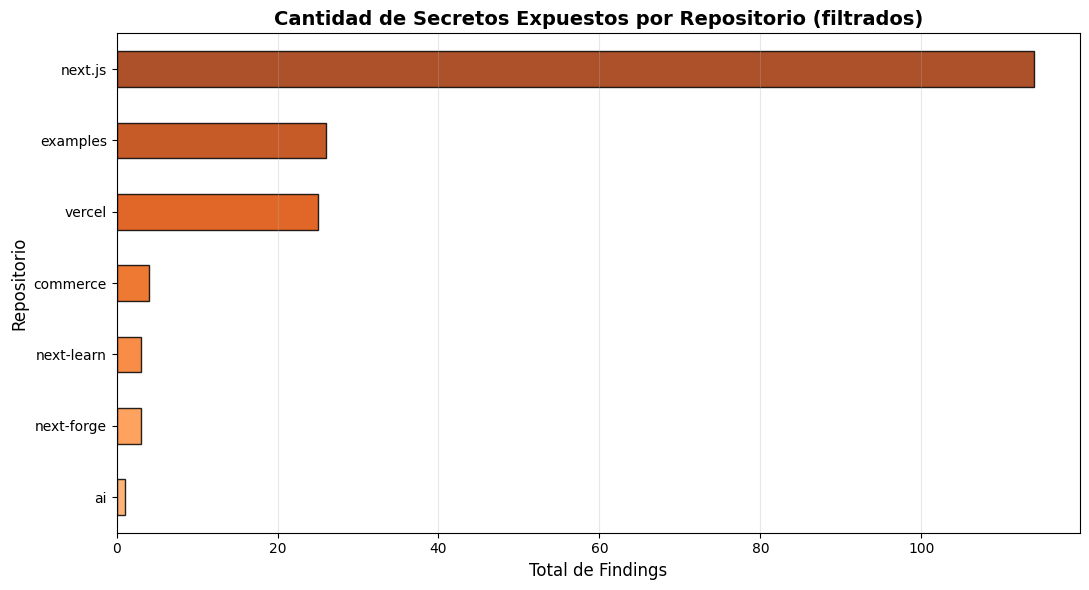

In [31]:
# Gráfico: Secretos por repositorio
if len(df_gitleaks) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))

    df_filtered = df_gitleaks[~df_gitleaks['File'].str.contains(
        pattern, case=False, na=False)]

    issues_por_repo = df_filtered['repo'].value_counts(
    ).sort_values(ascending=True)

    # Colores del gradiente
    colores_gradiente = plt.cm.Oranges(
        np.linspace(0.4, 0.9, len(issues_por_repo)))

    issues_por_repo.plot(
        kind='barh', ax=ax, color=colores_gradiente, edgecolor='black', alpha=0.85)

    ax.set_title('Cantidad de Secretos Expuestos por Repositorio (filtrados)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Total de Findings', fontsize=12)
    ax.set_ylabel('Repositorio', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para graficar")

In [32]:
# Descripción de 20 datos por repositorio filtrados
if len(df_gitleaks) > 0:
    df_filtered = df_gitleaks[~df_gitleaks['File'].str.contains(
        pattern, case=False, na=False)]

    for repo in df_filtered['repo'].unique()[:20]:
        print(f"\nRepositorio: {repo}")
        print("-" * 30)
        datos_repo = df_filtered[df_filtered['repo'] == repo]
        for _, row in datos_repo.iterrows():
            print(f"  - {row['File']}: {row['RuleID']}")


Repositorio: ai
------------------------------
  - content/cookbook/05-node/56-web-search-agent.mdx: generic-api-key

Repositorio: commerce
------------------------------
  - .env: jwt
  - .env: jwt
  - codegen.json: jwt
  - codegen.json: jwt

Repositorio: examples
------------------------------
  - framework-boilerplates/hydrogen/hydrogen.config.ts: generic-api-key
  - framework-boilerplates/hydrogen/hydrogen.config.ts: generic-api-key
  - solutions/book-inventory/.env: generic-api-key
  - edge-middleware/feature-flag-split/lib/split.ts: generic-api-key
  - edge-middleware/api-rate-limit/README.md: generic-api-key
  - edge-middleware/api-rate-limit-and-tokens/README.md: generic-api-key
  - edge-middleware/clerk-authentication/README.md: generic-api-key
  - edge-middleware/ip-blocking/README.md: generic-api-key
  - edge-middleware/redirects-upstash/README.md: generic-api-key
  - edge-middleware/redirects-upstash/README.md: generic-api-key
  - build-output-api/on-demand-isr/.vercel/out

## Análisis cualitativo de los resultados: 

Al analizar la organización de Vercel se puede apreciar en un inicio una gran cantidad de secretos encontrados, especialmente los de tipo _generic-api-key_ y _private-key_. Además, estos se centran principalmente en los repositorios de Next.JS y Vercel. Sin embargo, al revisar los archivos en busca de patrones y de una descripción detallada, se pudo apreciar que al menos la mitad de los resultados son falsos positivos que se encuentran en carpetas como "example", "docs" y "template", entre otras. Por lo tanto, se realiza un filtro para obtener la mayor cantidad de resultados significativos posibles.

Con el conjunto de datos filtrados se puede observar un cambio de tendencia, donde las cifras bajan, los tipos de llaves como las de AWS o Curl Auth Header son eliminados, y en repositorios como el de Vercel disminuye considerablemente el número de coincidencias. 

Posteriormente, al analizar cualitativa y manualmente los resultados obtenidos de _GitLeaks_, se evidencia que todos corresponden a falsos positivos. En la gran mayoría de los casos, se trata de archivos de configuración con _placeholders_ que utilizan el sufijo o prefijo API (por lo que la herramienta los clasifica como tal), o bien son _strings_ con la suficiente entropía para ser catalogadas como _secrets_. 

En consecuencia, estas "llaves" no pueden ser aprovechadas por un tercero. Sin embargo, es importante mencionar que la empresa debe tener cuidado de no ignorar alertas reales asumiendo que son falsos positivos. La filtración de llaves verdaderas como _generic-api-key_ o las de AWS pueden generar daños graves a la infraestructura o permitir el acceso a información sensible debido a la magnitud de la organización. Un ejemplo de esto es lo que sucedió con Uber en 2016, tras el acceso a claves que se encontraban embebidas en el código de un desarrollador, o, de forma muy similar, la brecha que sufrió Vercel en abril de este año, donde el equipo de un trabajador fue infectado al descargar trampas para el juego _Roblox_, permitiendo a los atacantes obtener acceso a su cuenta de Google y alcanzar datos de entorno.

Finalmente, se concluye que la organización de _Vercel_ presenta una gran cantidad de hallazgos que, en su totalidad, corresponden a falsos positivos, lo que pone en evidencia la importancia de realizar un análisis cualitativo sobre los resultados automatizados para obtener datos que reflejen la situación real de la organización.